In [24]:
from langgraph.graph import  StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver

In [25]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
  messages: Annotated[list[BaseMessage],add_messages]

In [26]:
from dotenv import load_dotenv
load_dotenv()

llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [27]:
def chat_node(state: ChatState)->ChatState:
  messages=state['messages']
  
  response=llm.invoke(messages)
  
  return {'messages':[response]}
  

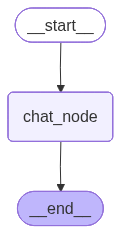

In [28]:

checkpointer=MemorySaver()

graph=StateGraph(ChatState)

graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)


chatbot=graph.compile(checkpointer=checkpointer)

chatbot

In [33]:
thread_id='1'

while True:
  
  user_message = input("Type here : ")
  print('\n\nUser : ',user_message)
  
  if user_message.strip().lower() in ['exit','quit','bye']:
    break
  
  config={'configurable':{'thread_id':thread_id}}
  response=chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config)
  
  print('AI : ',response['messages'][-1].content)



User :  eexit
AI :  It was nice chatting with you, Ved. If you want to talk again, feel free to come back anytime. Have a great day! Bye!


User :  exit
